# Xarray-Spatial Templates: from_template

Most analyses start from a raster you already have. `from_template` goes the
other way: name a study area and get back an empty, correctly projected grid to
build on. Pick the contiguous US in Albers, a metro area, or any country by its
ISO code, then fill it with your own data and run the rest of xarray-spatial on
it.

### What you'll build

1. A CONUS canvas in Albers Equal-Area, and a look at the array contract it
   follows.
2. The same area at a coarser and finer resolution.
3. A country grid pulled straight from an ISO code.
4. Synthetic terrain generated on the template and shaded with `hillshade`,
   showing it drops into the normal xarray-spatial workflow.

![preview](images/57_templates_preview.png)

Sections: [CONUS canvas](#A-CONUS-canvas-in-Albers) ·
[Resolution](#Choosing-a-resolution) ·
[Country codes](#Any-country-by-ISO-code) ·
[Filling the canvas](#Filling-the-canvas)

A small import block. Everything below uses xarray-spatial's own functions.

In [1]:
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

import xrspatial
from xrspatial import from_template, hillshade

## A CONUS canvas in Albers

`from_template("conus")` returns an empty grid covering the contiguous United
States in the USGS Albers Equal-Area projection (EPSG:5070). The values are all
NaN; what matters is the georeferencing the grid carries.

In [2]:
conus = from_template("conus")

print("dims: ", conus.dims)
print("shape:", conus.shape)
print("crs:  ", conus.attrs["crs"])
print("res:  ", tuple(round(r, 1) for r in conus.attrs["res"]), "(metres)")
print("all NaN:", bool(np.isnan(conus).all().item()))
conus

dims:  ('y', 'x')
shape: (621, 1173)
crs:   5070
res:   (4999.7, 5000.1) (metres)
all NaN: True


<xarray.DataArray 'conus' (y: 621, x: 1173)> Size: 3MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(621, 1173), dtype=float32)
Coordinates:
  * y        (y) float64 5kB 3.255e+06 3.25e+06 3.245e+06 ... 1.6e+05 1.55e+05
  * x        (x) float64 9kB -2.915e+06 -2.91e+06 ... 2.94e+06 2.945e+06
Attributes:
    res:      (4999.726342710997, 5000.103059581321)
    crs:      5070

The grid follows the xarray-spatial array contract: two dimensions named
`y` and `x`, pixel-center coordinates with `y` running north to south, and
`res` plus `crs` in the attributes. Any tool in the library can read it.

The grid is empty, so a plain plot would be blank. To see the georeferencing,
paint a smooth synthetic field from the coordinates and show that instead.

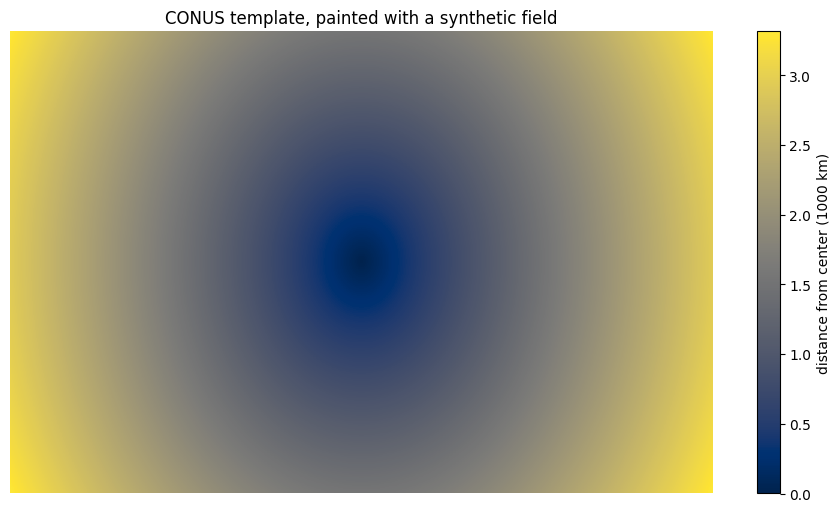

In [3]:
xx, yy = np.meshgrid(conus["x"], conus["y"])
cx = float(conus["x"].mean())
cy = float(conus["y"].mean())
radial = np.hypot(xx - cx, yy - cy) / 1e6  # distance from center, in 1000 km

painted = conus.copy(data=radial.astype("float32"))
painted.plot.imshow(size=6, aspect=conus.shape[1] / conus.shape[0],
                    cmap="cividis", cbar_kwargs={"label": "distance from center (1000 km)"})
plt.title("CONUS template, painted with a synthetic field")
plt.gca().set_axis_off()

<div class="alert alert-block alert-info">
<b>Bounding box, not a mask.</b> The template is the region's rectangular extent,
not its outline. Cells over the ocean or across a border are part of the grid.
Mask to a real boundary with <code>rasterize</code> or <code>xarray.where</code>
once you have a geometry.
</div>

## Choosing a resolution

`resolution` sets the cell size in the template's CRS units, metres here. Each
template ships with a default, so a bare call works, but you set your own when
you know the scale you need.

In [4]:
for res in (20000, 10000, 5000):
    grid = from_template("conus", resolution=res)
    print(f"{res:>6d} m cells -> {grid.shape[0]:>4d} x {grid.shape[1]:<4d}"
          f"  ({grid.size:,} cells)")

 20000 m cells ->  155 x 293   (45,415 cells)
 10000 m cells ->  311 x 586   (182,246 cells)
  5000 m cells ->  621 x 1173  (728,433 cells)


<div class="alert alert-block alert-warning">
<b>Cell count grows fast.</b> Halving the resolution quadruples the cell count.
A stray tiny resolution can ask for billions of cells, so <code>from_template</code>
refuses grids past a safety limit. Pick a resolution that matches your analysis,
not the finest number you can think of.
</div>

## Any country by ISO code

Pass an ISO-3166 / GADM alpha-3 code and you get that country's bounding box in
EPSG:4326 (longitude/latitude). 240 countries are covered. The extent spans the
whole territory, so a country with distant overseas regions gets a wide grid.

crs:   4326 (lon/lat)
shape: (212, 222)
bounds x: 123.73 -> 145.78
bounds y: 24.32 -> 45.46


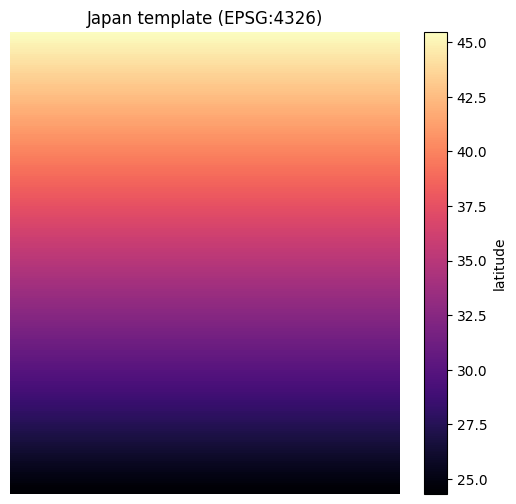

In [5]:
japan = from_template("JPN")
print("crs:  ", japan.attrs["crs"], "(lon/lat)")
print("shape:", japan.shape)
print("bounds x:", round(float(japan['x'].min()), 2), "->", round(float(japan['x'].max()), 2))
print("bounds y:", round(float(japan['y'].min()), 2), "->", round(float(japan['y'].max()), 2))

# paint a north-south gradient so the extent is visible
lat = japan['y'].broadcast_like(japan)
jp_painted = japan.copy(data=lat.values.astype('float32'))
jp_painted.plot.imshow(size=6, aspect=japan.shape[1] / japan.shape[0],
                       cmap='magma', cbar_kwargs={'label': 'latitude'})
plt.title('Japan template (EPSG:4326)')
plt.gca().set_axis_off()

<div class="alert alert-block alert-warning">
<b>Degrees are not metres.</b> Country templates are in longitude/latitude, so
Euclidean tools measure in degrees and distort with latitude. Reproject to a
local projected CRS, or use the great-circle options, before distance or slope
work. The projected regions such as <code>conus</code> already sidestep this.
</div>

## Filling the canvas

The point of a template is what you do next. Here a synthetic elevation surface
is painted into the CONUS grid from its own coordinates, then `hillshade` renders
it. The `hillshade` call is exactly the one you would run on real elevation
data; only the source of the values differs.

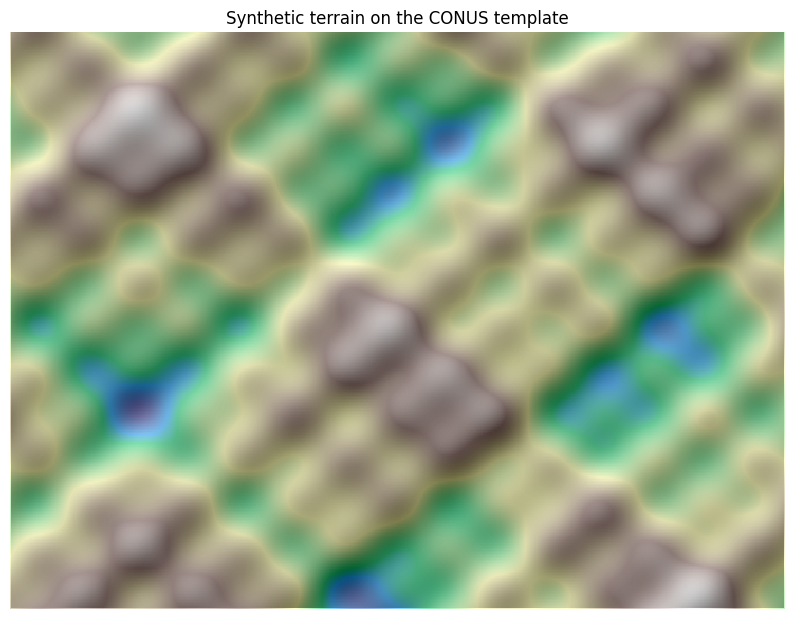

In [6]:
canvas = from_template("conus", resolution=8000)

# normalized coordinates, 0..1 across the grid
xn = (canvas["x"] - canvas["x"].min()) / (canvas["x"].max() - canvas["x"].min())
yn = (canvas["y"] - canvas["y"].min()) / (canvas["y"].max() - canvas["y"].min())
XN, YN = np.meshgrid(xn, yn)

# a few octaves of sinusoids stand in for rolling terrain
elev = (np.sin(3 * np.pi * XN) * np.cos(2.5 * np.pi * YN)
        + 0.5 * np.sin(7 * np.pi * XN + 1) * np.cos(6 * np.pi * YN)
        + 0.25 * np.sin(15 * np.pi * XN) * np.cos(13 * np.pi * YN + 2))
terrain = canvas.copy(data=(elev * 400 + 800).astype("float32"))
shaded = hillshade(terrain)

fig, ax = plt.subplots(figsize=(10, 7.5))
shaded.plot.imshow(ax=ax, cmap="gray", add_colorbar=False)
terrain.plot.imshow(ax=ax, cmap="terrain", alpha=120 / 255, add_colorbar=False)
ax.set_title("Synthetic terrain on the CONUS template")
ax.set_axis_off()

The elevation is invented, but the grid under it is a real CONUS Albers
canvas with metre coordinates and a CRS. Replace the painted array with
`open_geotiff` output and the `hillshade` step does not change.

### References

- USGS Albers Equal-Area (EPSG:5070): https://epsg.io/5070
- Natural Earth, source of the country bounding boxes: https://www.naturalearthdata.com/
- ISO 3166-1 alpha-3 country codes: https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3
- GADM administrative boundaries: https://gadm.org/